# Phase 4 — Region-partitioning MKNN read-out

This is the phase's real read-out notebook, not a `CLAUDE.md` sanity check — it legitimately
reads `notebooks/.cache/04_region_partition_mknn.jsonl`, the JSONL cache written by
`notebooks/diagnostics/region_partition_mknn_run.py`. All compute lives in that runner; this
notebook computes nothing heavy, following this repo's runner + JSONL cache + notebook pattern.

Sections: **0** provenance, **1** MKNN-01 (the metric, its known-answer checks, and why the
standing Swiss roll rule is not triggered here), **2** MKNN-02 (the global crossmodal
reproduction against the origin paper).

## Section 0 — Provenance

In [1]:
import subprocess
import sys
from pathlib import Path

# import pu_manifold and the diagnostics runner exactly as the other notebooks do -- relative,
# never from src/effdim/. "diagnostics" is an implicit namespace package (no __init__.py).
NOTEBOOK_DIR = Path.cwd()
if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))

import numpy as np
import scipy
import sklearn

from pu_manifold import curvature_probe, mknn
from diagnostics import region_partition_mknn_run as rpm

git_sha = subprocess.check_output(["git", "rev-parse", "--short", "HEAD"], text=True).strip()

X_hsc, X_ls, subsample_file = rpm.load_pu_pair()

print(f"resolved subsample file : {Path(subsample_file).name}")
print(f"row count                : {X_hsc.shape[0]}")
print(f"columns                  : hsc {X_hsc.shape}, legacysurvey {X_ls.shape}")
print(f"numpy                    : {np.__version__}")
print(f"scipy                    : {scipy.__version__}")
print(f"scikit-learn             : {sklearn.__version__}")
print(f"git HEAD                 : {git_sha}")
print(f"curvature_probe.CURVATURE_CONVENTION : {curvature_probe.CURVATURE_CONVENTION!r}")

loaded hsc (10000, 768) and legacysurvey (10000, 768) from subsample_20260729_a79b3460b838fd0a.npz
resolved subsample file : subsample_20260729_a79b3460b838fd0a.npz
row count                : 10000
columns                  : hsc (10000, 768), legacysurvey (10000, 768)
numpy                    : 2.5.1
scipy                    : 1.18.0
scikit-learn             : 1.9.0
git HEAD                 : bc60f38
curvature_probe.CURVATURE_CONVENTION : 'trace'


## Section 1 — MKNN-01: the metric and its sanity checks

**Formula** (Chechik et al. 2010, adopted verbatim by arXiv:2509.19453, cited here as the
direct, verified source):

$$\mathrm{MKNN}(z_1, z_2) = k^{-1} \, \bigl| N_k(z_1) \cap N_k(z_2) \bigr|$$

with $N_k(z)$ the k-NN index set within $z$'s own embedding space, self excluded. The paper
attributes the metric to Chechik et al. 2010; that attribution is repeated as the paper's own
citation choice here and was not independently re-verified (RESEARCH A2, disposed — see
`04-01-PLAN.md` `flagged_assumptions`).

In [2]:
rng = np.random.default_rng(20260822)


def check(name: str, cond: bool) -> None:
    print(f"  [{'PASS' if cond else 'FAIL'}] {name}")
    assert cond, name


X = rng.normal(size=(400, 16))
Y = X.copy()
check("identical row-aligned pair scores exactly 1.0 at k=10", mknn.mknn_score(X, Y, 10) == 1.0)

Z = rng.normal(size=(20, 8))
check("k = n - 1 scores exactly 1.0", mknn.mknn_score(Z, Z.copy(), 19) == 1.0)

A = rng.normal(size=(400, 16))
B = rng.normal(size=(400, 16))
ind_score = mknn.mknn_score(A, B, 10)
floor = mknn.chance_floor(400, 10)
check(
    "independent Gaussian clouds (400, 16) land within a factor of 3 of chance_floor(400, 10)",
    floor / 3.0 <= ind_score <= floor * 3.0,
)

perm = rng.permutation(400)
base = mknn.mknn_score(X, Y, 10)
check(
    "simultaneous row permutation of both sides leaves the score unchanged",
    mknn.mknn_score(X[perm], Y[perm], 10) == base,
)
check("permuting one side only changes the score", mknn.mknn_score(X, Y[perm], 10) != base)

print("\nAll MKNN-01 known-answer assertions pass (identical to --selfcheck's, run inline here).")

  [PASS] identical row-aligned pair scores exactly 1.0 at k=10
  [PASS] k = n - 1 scores exactly 1.0
  [PASS] independent Gaussian clouds (400, 16) land within a factor of 3 of chance_floor(400, 10)
  [PASS] simultaneous row permutation of both sides leaves the score unchanged
  [PASS] permuting one side only changes the score

All MKNN-01 known-answer assertions pass (identical to --selfcheck's, run inline here).


**Why `CLAUDE.md`'s standing Swiss roll rule is not triggered here (D4-12).** That rule
targets models that map data to a lower-dimensional representation and back, or that claim to
recover manifold structure — chart auto-encoders, topological auto-encoders, decoder
parameterizations, curvature estimators. MKNN learns nothing: it has no latent space, no
training, and no reconstruction. It is a metric computed directly on two given embeddings, and
this phase's sign-split partition (plan `04-03`) reads an already-computed vector field rather
than recovering manifold structure itself. The estimator underneath that field is already
covered by `notebooks/02.5_swiss_roll_curvature_probe_check.ipynb`. The rule is not being
waived here — it does not apply to either MKNN or the sign-split partition.

## Section 2 — MKNN-02: the global crossmodal reproduction

In [3]:
import json

CACHE = Path("notebooks/.cache") if Path("notebooks/.cache").exists() else Path(".cache")
RECORD_PATH = CACHE / "04_region_partition_mknn.jsonl"

rows = []
with RECORD_PATH.open() as fh:
    for line in fh:
        r = json.loads(line)
        if r.get("region") == "global":
            rows.append(r)

# one row per k -- the most recent row for each k_mknn (later runs at the same seed reproduce
# bit-identically, so "most recent" and "first" agree on every value that matters)
by_k = {}
for r in rows:
    by_k[r["k_mknn"]] = r
global_rows = [by_k[k] for k in sorted(by_k)]

print(f"{len(rows)} global rows on disk, {len(global_rows)} distinct k_mknn: {sorted(by_k)}")
rpm.summarize(global_rows)

6 global rows on disk, 4 distinct k_mknn: [5, 10, 20, 50]

Global crossmodal MKNN read-out, full grid:
 k_mknn       n    score%    floor%    ratio        p   ci_low%  ci_high%   hub_hsc    hub_ls
      5   10000     4.882      0.05   97.640   0.0010     4.688     5.086     1.239     1.494
     10   10000     6.594       0.1   65.940   0.0010     6.417     6.781     1.118     1.319
     20   10000      8.98       0.2   44.902   0.0010     8.802     9.165     1.049     1.188
     50   10000     13.23       0.5   26.458   0.0010     13.03     13.43     0.966     1.013

--- comparison against the origin paper (D4-19) ---
this run:  n = 10000, raw MKNN 4sf shown above per k, ratio-over-chance carries
           the comparison across the n mismatch, NOT the raw number
paper:     Legacy-vs-HSC published range 0.34% - 2.25% at n = 101725 (arXiv:2509.19453 Table 2)
NOTE: n = 10000 here vs n = 101725 in the paper -- raw numbers are NOT directly comparable across this n mismatch; the ratio-over-

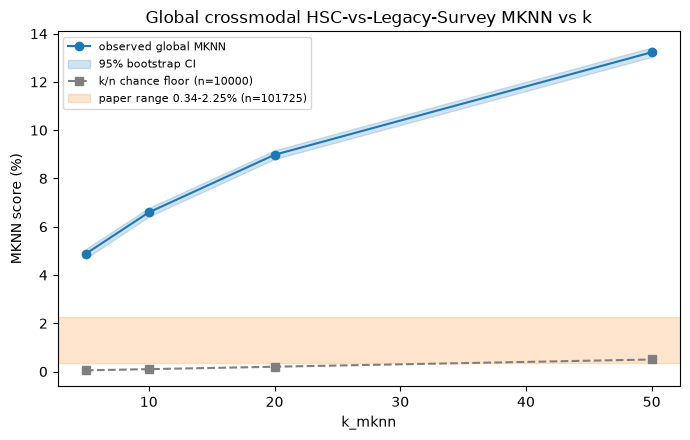

In [4]:
import matplotlib.pyplot as plt

ks = [r["k_mknn"] for r in global_rows]
scores_pct = [r["score"] * 100 for r in global_rows]
floors_pct = [r["chance_floor"] * 100 for r in global_rows]
ci_low_pct = [r["ci_low"] * 100 for r in global_rows]
ci_high_pct = [r["ci_high"] * 100 for r in global_rows]

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(ks, scores_pct, "o-", color="tab:blue", label="observed global MKNN")
ax.fill_between(
    ks,
    ci_low_pct,
    ci_high_pct,
    color="tab:blue",
    alpha=0.2,
    label="95% bootstrap CI",
)
ax.plot(ks, floors_pct, "s--", color="tab:gray", label="k/n chance floor (n=10000)")
ax.axhspan(
    rpm.PAPER_RANGE_LOW,
    rpm.PAPER_RANGE_HIGH,
    color="tab:orange",
    alpha=0.2,
    label=f"paper range {rpm.PAPER_RANGE_LOW}-{rpm.PAPER_RANGE_HIGH}% (n={rpm.PAPER_N})",
)
ax.set_xlabel("k_mknn")
ax.set_ylabel("MKNN score (%)")
ax.set_title("Global crossmodal HSC-vs-Legacy-Survey MKNN vs k")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [5]:
print("=== read-out ===")
for r in global_rows:
    inside = rpm.PAPER_RANGE_LOW <= r["score"] * 100 <= rpm.PAPER_RANGE_HIGH
    print(
        f"k={r['k_mknn']:>2}: score {r['score'] * 100:.4g}% is "
        f"{r['ratio_over_chance']:.2f}x its chance floor "
        f"({r['chance_floor'] * 100:.4g}%); "
        f"raw value falls {'INSIDE' if inside else 'OUTSIDE'} the paper's "
        f"{rpm.PAPER_RANGE_LOW}-{rpm.PAPER_RANGE_HIGH}% band (not directly comparable -- "
        f"n={r['n']} here vs n={rpm.PAPER_N} in the paper)"
    )

print(
    f"\nn mismatch stated plainly: this run is n={global_rows[0]['n']}, the paper's "
    f"Table 2 column is n={rpm.PAPER_N} -- an {rpm.PAPER_N / global_rows[0]['n']:.1f}x "
    "difference in sample size. Per D4-19, the ratio-over-chance is what carries the "
    "comparison across that mismatch, not the raw percentage falling inside or outside the "
    "band."
)

print("\n=== MKNN-08 hubness caveat, substantiated ===")
for r in global_rows:
    print(
        f"k={r['k_mknn']:>2}: k-occurrence skewness hsc={r['hubness_skewness_hsc']:.3f}, "
        f"legacysurvey={r['hubness_skewness_legacysurvey']:.3f}"
    )
hub_all = [r["hubness_skewness_hsc"] for r in global_rows] + [
    r["hubness_skewness_legacysurvey"] for r in global_rows
]
print(
    f"\nEvery MKNN result above carries the hubness caveat: k-NN alignment metrics are "
    "hubness-sensitive in high dimensions (Radovanovic, Nanopoulos and Ivanovic, JMLR 2010), "
    f"and the printed k-occurrence skewness (ranges {min(hub_all):.3f} to {max(hub_all):.3f} "
    "here, both embedding sides, every k) is the substantiating evidence for that caveat "
    "rather than a prose-only assertion of it."
)

=== read-out ===
k= 5: score 4.882% is 97.64x its chance floor (0.05%); raw value falls OUTSIDE the paper's 0.34-2.25% band (not directly comparable -- n=10000 here vs n=101725 in the paper)
k=10: score 6.594% is 65.94x its chance floor (0.1%); raw value falls OUTSIDE the paper's 0.34-2.25% band (not directly comparable -- n=10000 here vs n=101725 in the paper)
k=20: score 8.98% is 44.90x its chance floor (0.2%); raw value falls OUTSIDE the paper's 0.34-2.25% band (not directly comparable -- n=10000 here vs n=101725 in the paper)
k=50: score 13.23% is 26.46x its chance floor (0.5%); raw value falls OUTSIDE the paper's 0.34-2.25% band (not directly comparable -- n=10000 here vs n=101725 in the paper)

n mismatch stated plainly: this run is n=10000, the paper's Table 2 column is n=101725 -- an 10.2x difference in sample size. Per D4-19, the ratio-over-chance is what carries the comparison across that mismatch, not the raw percentage falling inside or outside the band.

=== MKNN-08 hubnes